In [1]:
import numpy as np
import pandas as pd
import scipy
import scipy.stats
import matplotlib as mpl   
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import t, norm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
def get_stock_data(ticker, max, start_date, end_date):
    try:
        # https://medium.com/nerd-for-tech/all-you-need-to-know-about-yfinance-yahoo-finance-library-fa4c6e48f08e
        data = yf.Ticker(ticker)
        if max == False:
            data = data.history(start=start_date, end=end_date)
        else:
            data = data.history(period="max")
        return data
    except Exception as e:
        return f"Error fetching data: {e}"

In [3]:
#demo index
stock_data = get_stock_data("PREIX", False,"2000-01-01", "2024-10-01")
stock_data.asfreq('B').index  # set index frequency to business daliy
stock_data['Daily Return'] = stock_data['Close'].pct_change()  # percentage return

In [4]:
#simple threshold determination (based on SD, mean, etc. -- to be experimented with)

mean_return = stock_data['Daily Return'].mean()
std_return = stock_data['Daily Return'].std()

# Define thresholds
up_threshold = mean_return + std_return
down_threshold = mean_return - std_return

def classify_state(return_value, up_thresh, down_thresh):
    if return_value > up_thresh:
        return 'Up'
    elif return_value < down_thresh:
        return 'Down'
    else:
        return 'Stagnant'

stock_data['Markov State'] = stock_data['Daily Return'].apply(lambda x: classify_state(x, up_threshold, down_threshold))

In [5]:
#setting up predictors for updated transition matrix
features = [
    'close250',
    'ema30',
    'logPriceSlope',
    'rv20',
    'rvz',
    'rsi14'
]

def rolling_log_slope(series, window):
    x = np.arange(window)
    
    def slope(y):
        # y is log price in the window
        return np.polyfit(x, y, 1)[0]
    
    return series.rolling(window).apply(slope, raw=True)

def compute_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

#transDet = pd.DataFrame(columns=['Markov State'])
def set_stock_data(df):
    out = pd.DataFrame(index=df.index)
    #markov state param (?)
    #transDet['Markov State'] = df['Markov State']

    #close ratio param
    rolling_averages = df['Close'].rolling(250).mean()
    out['close250'] = df["Close"] / rolling_averages

    #ema ratio param
    ema = df["Close"].ewm(span=30, min_periods=30).mean()
    out['ema30'] = df["Close"] / ema

    #rolling slope of lop price param
    log_price = np.log(df['Close'])
    out['logPriceSlope'] = rolling_log_slope(log_price, 20)

    #rolling realized vol 20 day period param
    out['rv20'] = log_price.rolling(window=20).std() * np.sqrt(252)

    #rolling realized vol z-score based on prev data param
    out['rv252'] = log_price.rolling(window=252).std() * np.sqrt(252)
    out['rvz'] = (out['rv20'] - out['rv252'].mean()) / out['rv252'].std()
    out = out.drop(columns=['rv252'])

    #rsi over 14 days param
    out['rsi14'] = compute_rsi(df)
    return out

transDet = set_stock_data(stock_data).dropna()
scaler = StandardScaler()
#transDet.info()
X = scaler.fit_transform(transDet[features])

In [6]:
#transition matrix creation (probabilities of achieving various states based on prev states)

# Shift 'Markov State' column to get previous state
stock_data['Prev State'] = stock_data['Markov State'].shift(1)

# Create a transition matrix and Normalize to get probabilities
transition_counts = pd.crosstab(stock_data['Prev State'], stock_data['Markov State'])
#transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

In [7]:
#implementing Logistic Regression to improve informed transitions
transition_models = {}

# states = stock_data['Prev State'].unique()

# print(transDet.isna().sum())    # Should be 0
# print(len(X), len(stock_data))  # Should match after alignment
prev_state_aligned = stock_data.loc[transDet.index, 'Prev State']
next_state_aligned = stock_data.loc[transDet.index, 'Markov State']

states = prev_state_aligned.unique()

for state in states:
    idx = prev_state_aligned == state
    X_state = X[idx]
    y_state = next_state_aligned[idx]

    # Safety check
    if len(X_state) == 0:
        print(f"Skipping state {state} (no data)")
        continue

    model = LogisticRegression( #we're going to go with autoregression instead
        solver='lbfgs',
        max_iter=1000,
        class_weight="balanced",
        C=0.1 # default is one, does this help? 0.01 needed?
    )
    model.fit(X_state, y_state)

    transition_models[state] = model

In [8]:

def build_transition_matrix(transition_models, X, prev_states, all_states):
    """
    Build transition matrix using trained logistic models.

    Parameters:
        transition_models : dict[state] -> trained LogisticRegression
        X : feature matrix aligned with prev_states
        prev_states : array of previous states aligned with X
        all_states : sorted list of all possible states

    Returns:
        transition_matrix : (n_states x n_states)
    """

    n_states = len(all_states)
    state_to_index = {s: i for i, s in enumerate(all_states)}
    transition_matrix = np.zeros((n_states, n_states))

    for state in all_states:
        if state not in transition_models:
            continue

        model = transition_models[state]
        idx = prev_states == state
        X_state = X[idx]

        if len(X_state) == 0:
            continue

        # Predict probabilities for each observation
        probs = model.predict_proba(X_state.values)

        # Average predicted probabilities
        avg_probs = probs.mean(axis=0)

        # Map model.classes_ to correct column indices
        for class_label, prob in zip(model.classes_, avg_probs):
            j = state_to_index[class_label]
            i = state_to_index[state]
            transition_matrix[i, j] = prob

    return transition_matrix



In [9]:
#implementing Logistic Regression to improve informed transitions
transition_models = {}

# states = stock_data['Prev State'].unique()

# print(transDet.isna().sum())    # Should be 0
# print(len(X), len(stock_data))  # Should match after alignment
prev_state_aligned = stock_data.loc[transDet.index, 'Prev State']
next_state_aligned = stock_data.loc[transDet.index, 'Markov State']

states = prev_state_aligned.unique()

for state in states:
    idx = prev_state_aligned == state
    X_state = X[idx]
    y_state = next_state_aligned[idx]

    # Safety check
    if len(X_state) == 0:
        print(f"Skipping state {state} (no data)")
        continue

    model = LogisticRegression( #we're going to go with autoregression
        solver='lbfgs',
        max_iter=1000,
        class_weight="balanced",
        C=0.01 # default is one, does this help? 0.01 needed?
    )
    model.fit(X_state, y_state)

    transition_models[state] = model

In [10]:
#establish stationary equilibrium matrix

# def find_equilibrium(transition_matrix): #need to implement s.t. model is used rather than stationary matrix
#     # Add a small number to ensure the matrix is not singular
#     transition_matrix = transition_matrix + 1e-6
#     # Initialize the equilibrium vector
#     equilibrium = np.random.rand(transition_matrix.shape[0])
#     # Normalize the equilibrium vector
#     equilibrium = equilibrium / np.sum(equilibrium)
#     # Iterate until convergence
#     while True:
#         new_equilibrium = np.dot(equilibrium, transition_matrix)
#         # Check for convergence
#         if np.allclose(equilibrium, new_equilibrium):
#             break
#         # Update the equilibrium vector
#         equilibrium = new_equilibrium
#     return equilibrium

# # Calculate transition matrix

def find_equilibrium_from_matrix(P):
    """
    Compute stationary distribution using eigen decomposition.
    """
    eigvals, eigvecs = np.linalg.eig(P.T)

    # Find eigenvalue closest to 1
    idx = np.argmin(np.abs(eigvals - 1))
    stationary = np.real(eigvecs[:, idx])

    # Normalize
    stationary = stationary / stationary.sum()

    return stationary

P_model = build_transition_matrix(transition_models, transDet[features], prev_state_aligned, prev_state_aligned.unique())
state_order_target = ["Down", "Stagnant", "Up"]
state_order_logistic = ["Stagnant", "Down", "Up"]

P_model = pd.DataFrame(
    P_model,
    index=state_order_logistic,
    columns=state_order_logistic
)
P_model = P_model.reindex(
    index=state_order_target,
    columns=state_order_target
)

alpha = 0.7
empirical = pd.crosstab(
    stock_data['Prev State'],
    stock_data['Markov State']
)
empirical = empirical.div(empirical.sum(axis=1), axis=0)
P_final = alpha * P_model + (1 - alpha) * empirical
equilibrium = find_equilibrium_from_matrix(P_final)
print(P_final)

              Down  Stagnant        Up
Down      0.047713  0.198129  0.754158
Stagnant  0.028595  0.946332  0.025073
Up        0.049919  0.911249  0.038833


In [11]:
print(equilibrium)

[0.03018981 0.92206923 0.04774096]


In [12]:
def set_stock_data_simulation(sim_returns, init_price):
    """
    sim_returns: list or np.array of simulated log returns
    init_price: last observed real Close price
    """

    sim_returns = np.asarray(sim_returns)

    # reconstruct price path
    prices = init_price * np.exp(np.cumsum(sim_returns))
    df = pd.DataFrame({"Close": prices})

    out = pd.DataFrame()

    # close / SMA250
    rolling_averages = df['Close'].rolling(250).mean()
    out['close250'] = df['Close'] / rolling_averages

    # EMA30
    ema = df['Close'].ewm(span=30, min_periods=30).mean()
    out['ema30'] = df['Close'] / ema

    # rolling slope of log price
    log_price = np.log(df['Close'])
    out['logPriceSlope'] = rolling_log_slope(log_price, 20)

    # realized volatility
    out['rv20'] = log_price.rolling(20).std() * np.sqrt(252)
    out['rv252'] = log_price.rolling(252).std() * np.sqrt(252)
    out['rvz'] = (out['rv20'] - out['rv252'].mean()) / out['rv252'].std()
    out = out.drop(columns=['rv252'])

    # RSI
    out['rsi14'] = compute_rsi(df)

    return out.iloc[-1]  # return today's features only


In [13]:
from sklearn.metrics import accuracy_score, classification_report
transDet["Markov State"] = stock_data["Markov State"]
transDet["Next State"] = stock_data["Markov State"].shift(-1)
for state, model in transition_models.items():
    # Select rows where current state is 'state' and next state exists
    idx = (transDet['Markov State'] == state) & (transDet['Next State'].notna())
    
    X_state = scaler.transform(transDet.loc[idx, features])
    y_true = transDet.loc[idx, 'Next State']
    
    y_pred = model.predict(X_state)
    acc = accuracy_score(y_true, y_pred)
    print(f"{state}: next-state prediction accuracy = {acc:.2f}")
    print(classification_report(y_true, y_pred, digits=3))

Stagnant: next-state prediction accuracy = 0.63
              precision    recall  f1-score   support

        Down      0.172     0.375     0.236       437
    Stagnant      0.923     0.695     0.793      3932
          Up      0.135     0.292     0.185       390

    accuracy                          0.633      4759
   macro avg      0.410     0.454     0.405      4759
weighted avg      0.789     0.633     0.692      4759

Down: next-state prediction accuracy = 0.55
              precision    recall  f1-score   support

        Down      0.225     0.376     0.281       101
    Stagnant      0.782     0.689     0.733       412
          Up      0.288     0.244     0.264       123

    accuracy                          0.553       636
   macro avg      0.432     0.436     0.426       636
weighted avg      0.598     0.553     0.571       636

Up: next-state prediction accuracy = 0.54
              precision    recall  f1-score   support

        Down      0.299     0.418     0.349      

normalizing vectors vs normalizing matrices? research further to ensure you fully comprehend

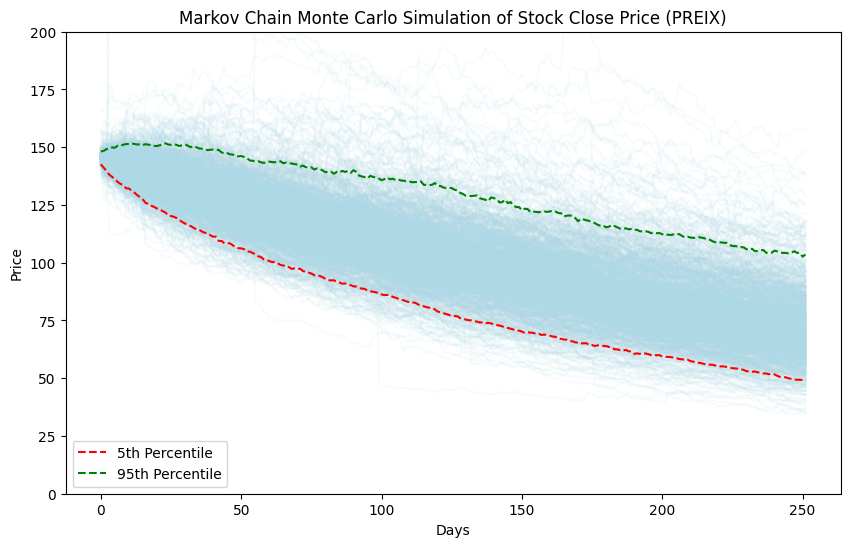

In [14]:
#mc sim

# Fit the Student's t distribution to the returns data
params = t.fit(stock_data['Daily Return'].dropna())

# Get the parameters of the distribution
df_t, mu, sigma = params

# state_params = {}

# for state in states:
#     state_returns = stock_data.loc[
#         stock_data['Markov State'] == state,
#         'Daily Return'
#     ].dropna()

#     state_params[state] = t.fit(state_returns)

# from above
#print("Transition Matrix:\n", transition_matrix)
initial_price = stock_data['Close'].iloc[-1]  # Initial stock price
states = ["Up", "Down", "Stagnant"]

# 4. Monte Carlo Simulation based on Markov Chain
n_simulations = 1000  # Number of simulation paths
n_days = 252  # Simulate for 1 year (252 trading days)

# Initial state probabilities
initial_state = stock_data['Markov State'].iloc[-1]
initial_state_probabilities = [1 if state == initial_state else 0 for state in states]

# Simulating the paths
simulated_paths = []
for sim in range(n_simulations):
    simulated_returns = []
    current_state = np.random.choice(states, p=initial_state_probabilities)
    
    for day in range(n_days):
        #Simulate return based on the current state using Student's t-distribution
        if current_state == "Up":
            daily_return = t.rvs(df_t, loc=mu + sigma, scale=sigma)
        elif current_state == "Down":
            daily_return = t.rvs(df_t, loc=mu - sigma, scale=sigma)
        else:
            daily_return = t.rvs(df_t, loc=mu, scale=sigma)

        # df_s, mu_s, sigma_s = state_params[current_state]
        # daily_return = t.rvs(df_s, loc=mu_s, scale=sigma_s)
        
        simulated_returns.append(daily_return)
        # Transition to the next state based on the transition matrix
        #current_state = np.random.choice(states, p=transition_matrix.loc[current_state].values)
        
        if len(simulated_returns) >= 253:
            feat_values = set_stock_data_simulation(simulated_returns[-253:], daily_return)
            x_today = scaler.transform(pd.DataFrame([feat_values], columns=features))
            probs = transition_models[current_state].predict_proba(x_today)[0]
        else:
            today_features_df = pd.DataFrame([transDet.iloc[-1][features].values], columns=features)
            x_today = scaler.transform(today_features_df)
            probs = P_final.loc[current_state].values

        # today_features_df = pd.DataFrame([transDet.iloc[-1][features].values], columns=features)
        # x_today = scaler.transform(today_features_df)
        # probs = transition_models[current_state].predict_proba(x_today)[0]
        next_state = np.random.choice(states, p=probs)
        current_state = next_state

    
    # Cumulative price based on returns
    simulated_prices = initial_price * np.exp(np.cumsum(simulated_returns))
    simulated_paths.append(simulated_prices)

# Convert the list of paths to a DataFrame
simulated_paths_df = pd.DataFrame(simulated_paths).T

# 5. Plotting the Monte Carlo simulation
plt.figure(figsize=(10, 6))
plt.plot(simulated_paths_df, color="lightblue", alpha=0.1)

# Add 5% and 95% percentile lines
percentiles_5 = simulated_paths_df.quantile(0.05, axis=1)
percentiles_95 = simulated_paths_df.quantile(0.95, axis=1)

plt.plot(percentiles_5, color="red", linestyle="--", label="5th Percentile")
plt.plot(percentiles_95, color="green", linestyle="--", label="95th Percentile")

# Add labels and title
ticker = "PREIX" #demo ticker remember
plt.title(f"Markov Chain Monte Carlo Simulation of Stock Close Price ({ticker})")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.ylim(0, 200)
plt.show()


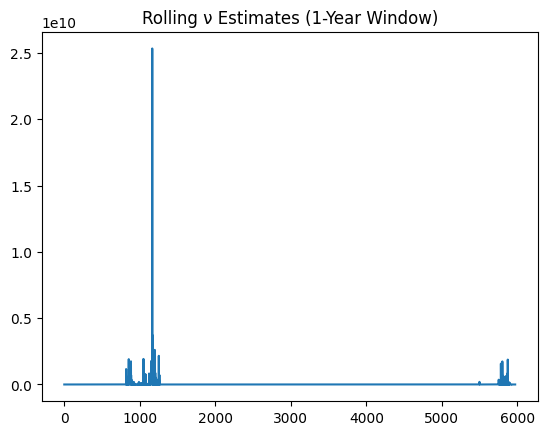

Mean ν: 16890118.30799075
Std ν: 348310409.66705966


In [26]:
window = 252
nus = []

returns = stock_data['Daily Return'].values
returns = stock_data['Daily Return'].values
returns = returns[np.isfinite(returns)]

for i in range(len(returns) - window):
    sample = returns[i:i+window]
    params = t.fit(sample)
    nus.append(params[0])  # df is first parameter

import matplotlib.pyplot as plt

plt.plot(nus)
plt.title("Rolling ν Estimates (1-Year Window)")
plt.show()

print("Mean ν:", np.mean(nus))
print("Std ν:", np.std(nus))

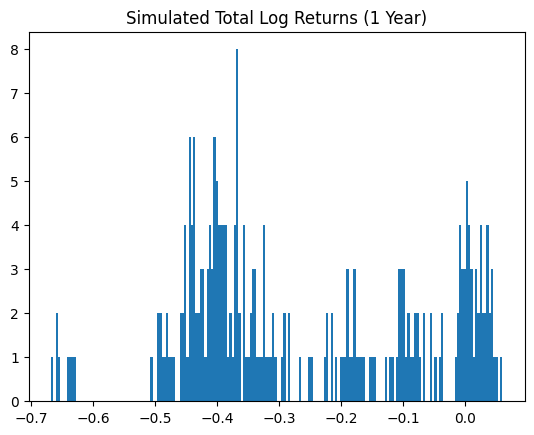

Sim mean: -0.2610946029204341
Sim median: -0.3342314748649452


In [19]:
final_prices = simulated_paths_df.iloc[:, -1]

sim_total_log_return = np.log(final_prices / initial_price)

plt.hist(sim_total_log_return, bins=200)
plt.title("Simulated Total Log Returns (1 Year)")
plt.show()

print("Sim mean:", sim_total_log_return.mean())
print("Sim median:", np.median(sim_total_log_return))



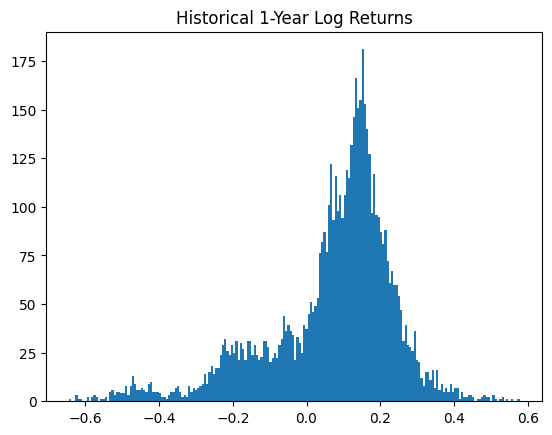

Real mean: 0.07083006408871113
Real median: 0.11231223914802331


In [20]:
log_returns = np.log(1 + stock_data['Daily Return'])

rolling_real = log_returns.rolling(252).sum().dropna()

plt.hist(rolling_real, bins=200)
plt.title("Historical 1-Year Log Returns")
plt.show()

print("Real mean:", rolling_real.mean())
print("Real median:", rolling_real.median())

In [ ]:
#mc extra adds

# 6. Computing VaR (Value at Risk)
final_prices = simulated_paths_df.iloc[-1]
losses = initial_price - final_prices
confidence_level = 0.95

# VaR at 95% confidence level
var_95 = np.percentile(losses, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at 95% confidence level: {var_95:.2f}")

# 7. Computing Confidence Intervals
mean_final_price = np.mean(final_prices)
std_final_price = np.std(final_prices)
ci_95 = norm.interval(0.95, loc=mean_final_price, scale=std_final_price)

print(f"95% Confidence Interval for the final price: {ci_95}")

Value at Risk (VaR) at 95% confidence level: 42.36
95% Confidence Interval for the final price: (np.float64(39.59704387159372), np.float64(106.04234395855966))


In [ ]:
print(np.mean(stock_data['Daily Return']))
print(np.mean(np.random.standard_t(df_t, size=1000000) * sigma))

0.00036492749919536725
-1.7499219798695188e-05


In [22]:
print(np.mean(np.log(1 + stock_data['Daily Return'])))


0.0002897608191166948


In [24]:
sigma

np.float64(0.007115765306575732)

In [ ]:
# 1. Check daily return stats
print(stock_data['Daily Return'].describe())

# 2. Check Student's t parameters
print(df_t, mu, sigma)

# 3. Check example simulated path
example_path = initial_price * np.exp(np.cumsum(np.random.standard_t(df_t, size=252) * sigma))
print(example_path[:10])  # first 10 days


count    6224.000000
mean        0.000365
std         0.012247
min        -0.119779
25%        -0.004761
50%         0.000656
75%         0.006001
max         0.116819
Name: Daily Return, dtype: float64
2.6654229880480944 0.0007116738576587495 0.007115765306575732
[143.44735935 145.4275325  145.19028997 144.97483055 147.35876302
 147.65478063 143.87016273 148.60263475 148.9477168  149.58077061]
